In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class RealisticMockDataGenerator:
    """
    Generador estocástico avanzado que simula la dinámica de los ciclos de mercado (Wyckoff)
    inyectando ruido financiero realista (colas pesadas y agrupamiento de volatilidad).
    """
    def __init__(self, steps=1000, cycle_length=250):
        self.steps = steps
        t = np.arange(steps)
        
        # 1. Simulación del Ciclo Base (Wyckoff)
        base_cycle = np.sin(2 * np.pi * t / cycle_length)
        
        # 2. Inyección de Ruido Financiero (Colas Pesadas)
        # Sustituimos el Random Walk gaussiano por una distribución t de Student (df=3)
        # Esto genera "shocks" repentinos y colas pesadas típicas de los retornos financieros reales.
        market_noise = np.random.standard_t(df=3, size=steps) * 0.8
        
        # Precio simulado: Tendencia cíclica + Ruido estocástico acumulado
        self.prices = 100 + (base_cycle * 20) + np.cumsum(market_noise)
        self.prices = np.maximum(self.prices, 1.0) # Prevención de precios negativos
        
        # 3. Simulación de Volatilidad (Volatility Clustering)
        # Extraemos los rendimientos logarítmicos continuos
        returns = np.diff(self.prices, prepend=self.prices[0]) / self.prices[0]
        
        # Simulamos el agrupamiento de volatilidad (efectos tipo GARCH)
        # La volatilidad reacciona exponencialmente a los shocks del precio
        garch_effect = np.abs(returns) * 12
        synthetic_volatility = garch_effect + np.random.lognormal(-2.5, 0.4, steps)
        self.volatility = np.clip(synthetic_volatility, 0.0, 1.0)
        
        # 4. Simulación del Sentimiento NLP (Ruidoso y Ambiguo)
        # Calculamos el momento del precio
        momentum = np.gradient(self.prices)
        raw_sentiment = np.tanh(momentum / 3.0)
        
        # Inyectamos un ruido significativo para emular la confusión crítica entre clases
        # positivas y neutrales que presenta FinBERT en textos ambiguos.
        nlp_noise = np.random.normal(0, 0.5, steps) 
        self.sentiment = np.clip(raw_sentiment + nlp_noise, -1.0, 1.0)

    def get_step_data(self, step):
        """
        Retorna el vector de estado del mercado para el timestep actual.
        """
        return self.prices[step], self.sentiment[step], self.volatility[step]

Generando 1000 observaciones simuladas...


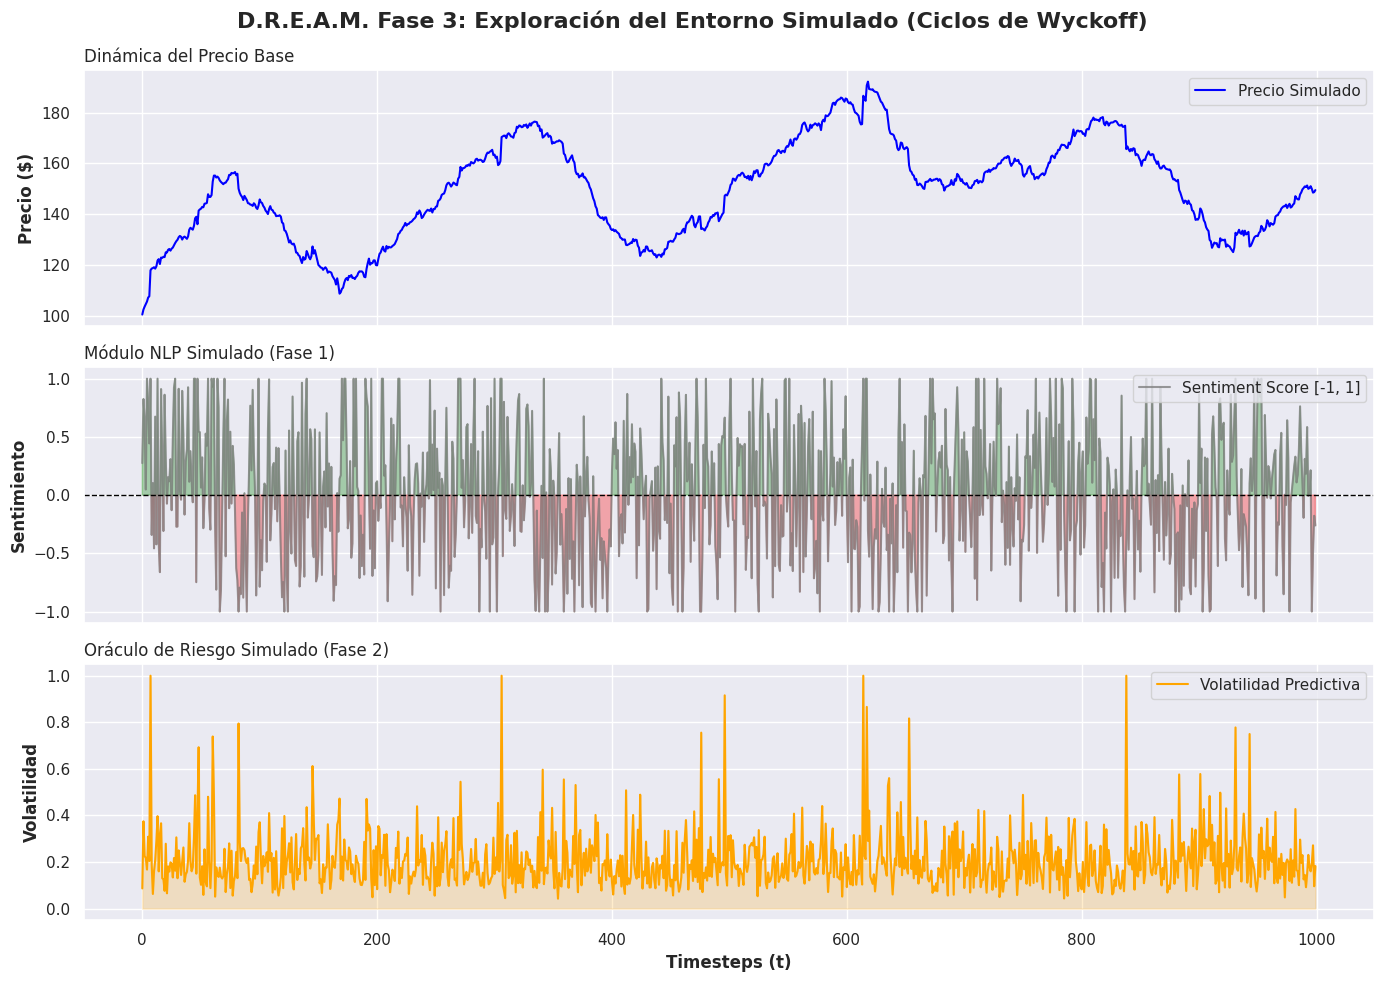


Resumen Estadístico de las Señales Simuladas:


,count,mean,std,min,25%,50%,75%,max
Step,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Price,1000.0,149.523312,18.892689,100.393396,133.868060,151.696393,163.285687,192.286024
Sentiment,1000.0,0.011345,0.551993,-1.000000,-0.397202,0.010790,0.399377,1.000000
Volatility,1000.0,0.207694,0.123535,0.042715,0.129762,0.181522,0.254303,1.000000


In [3]:
# Configuración de estilo para un entorno profesional de Finanzas Cuantitativas
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['lines.linewidth'] = 1.5

def explore_mock_data(generator, steps=1000):
    """
    Función de exploración visual para validar la correlación matemática 
    entre Precio, Sentimiento (Fase 1) y Volatilidad (Fase 2) simulados.
    """
    print(f"Generando {steps} observaciones simuladas...")
    
    # Extraer los datos del generador
    prices = np.zeros(steps)
    sentiments = np.zeros(steps)
    volatilities = np.zeros(steps)
    
    for t in range(steps):
        p, s, v = generator.get_step_data(t)
        prices[t] = p
        sentiments[t] = s
        volatilities[t] = v
        
    # Crear un DataFrame para facilitar la manipulación y el ploteo
    df = pd.DataFrame({
        'Step': range(steps),
        'Price': prices,
        'Sentiment': sentiments,
        'Volatility': volatilities
    })
    
    # Creación del Dashboard con 3 subplots compartiendo el eje X
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.suptitle('D.R.E.A.M. Fase 3: Exploración del Entorno Simulado (Ciclos de Wyckoff)', fontsize=16, fontweight='bold')
    
    # 1. Gráfico de Precio (Simulando Markup, Distribución, Markdown, Acumulación)
    ax1.plot(df['Step'], df['Price'], color='blue', label='Precio Simulado')
    ax1.set_ylabel('Precio ($)', fontweight='bold')
    ax1.set_title('Dinámica del Precio Base', loc='left')
    ax1.legend(loc='upper right')
    
    # 2. Gráfico de Sentimiento (FinBERT Mock)
    # Coloreamos positvo (verde) y negativo (rojo) para ver la euforia y el pánico
    ax2.fill_between(df['Step'], 0, df['Sentiment'], where=(df['Sentiment'] >= 0), color='green', alpha=0.3, interpolate=True)
    ax2.fill_between(df['Step'], 0, df['Sentiment'], where=(df['Sentiment'] < 0), color='red', alpha=0.3, interpolate=True)
    ax2.plot(df['Step'], df['Sentiment'], color='gray', alpha=0.8, label='Sentiment Score [-1, 1]')
    ax2.set_ylabel('Sentimiento', fontweight='bold')
    ax2.set_title('Módulo NLP Simulado (Fase 1)', loc='left')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.legend(loc='upper right')
    
    # 3. Gráfico de Volatilidad Predictiva
    ax3.plot(df['Step'], df['Volatility'], color='orange', label='Volatilidad Predictiva')
    ax3.fill_between(df['Step'], 0, df['Volatility'], color='orange', alpha=0.2)
    ax3.set_ylabel('Volatilidad', fontweight='bold')
    ax3.set_xlabel('Timesteps (t)', fontweight='bold')
    ax3.set_title('Oráculo de Riesgo Simulado (Fase 2)', loc='left')
    ax3.legend(loc='upper right')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Imprimir estadísticas descriptivas básicas
    print("\nResumen Estadístico de las Señales Simuladas:")
    display(df.describe().T)

# Instanciamos el generador con ciclos de 250 pasos (aprox. un año de trading)
mock_generator = RealisticMockDataGenerator(steps=1000, cycle_length=250)

# Ejecutamos la exploración en el notebook
explore_mock_data(mock_generator, steps=1000)

In [4]:
class RealisticMockDataGenerator2:
    def __init__(self, steps=1000, cycle_length=250):
        self.steps = steps
        self.cycle_length = cycle_length
        self.generate_new_market() # Genera el primer mercado al instanciar

    def generate_new_market(self):
        """Regenera toda la serie temporal estocástica para evitar overfitting."""
        t = np.arange(self.steps)
        
        # Inyectamos una variación aleatoria en la longitud del ciclo para que no sea siempre igual
        dynamic_cycle = self.cycle_length * np.random.uniform(0.8, 1.2)
        base_cycle = np.sin(2 * np.pi * t / dynamic_cycle)
        
        market_noise = np.random.standard_t(df=3, size=self.steps) * 0.8
        
        # Variamos el precio inicial aleatoriamente entre 50 y 150
        start_price = np.random.uniform(50.0, 150.0)
        self.prices = start_price + (base_cycle * 20) + np.cumsum(market_noise)
        self.prices = np.maximum(self.prices, 1.0) 
        
        returns = np.diff(self.prices, prepend=self.prices[0]) / self.prices[0]
        garch_effect = np.abs(returns) * 12
        synthetic_volatility = garch_effect + np.random.lognormal(-2.5, 0.4, self.steps)
        self.volatility = np.clip(synthetic_volatility, 0.0, 1.0)
        
        momentum = np.gradient(self.prices)
        raw_sentiment = np.tanh(momentum / 3.0)
        nlp_noise = np.random.normal(0, 0.5, self.steps) 
        self.sentiment = np.clip(raw_sentiment + nlp_noise, -1.0, 1.0)

    def get_step_data(self, step):
        return self.prices[step], self.sentiment[step], self.volatility[step]

Generando 1000 observaciones simuladas...


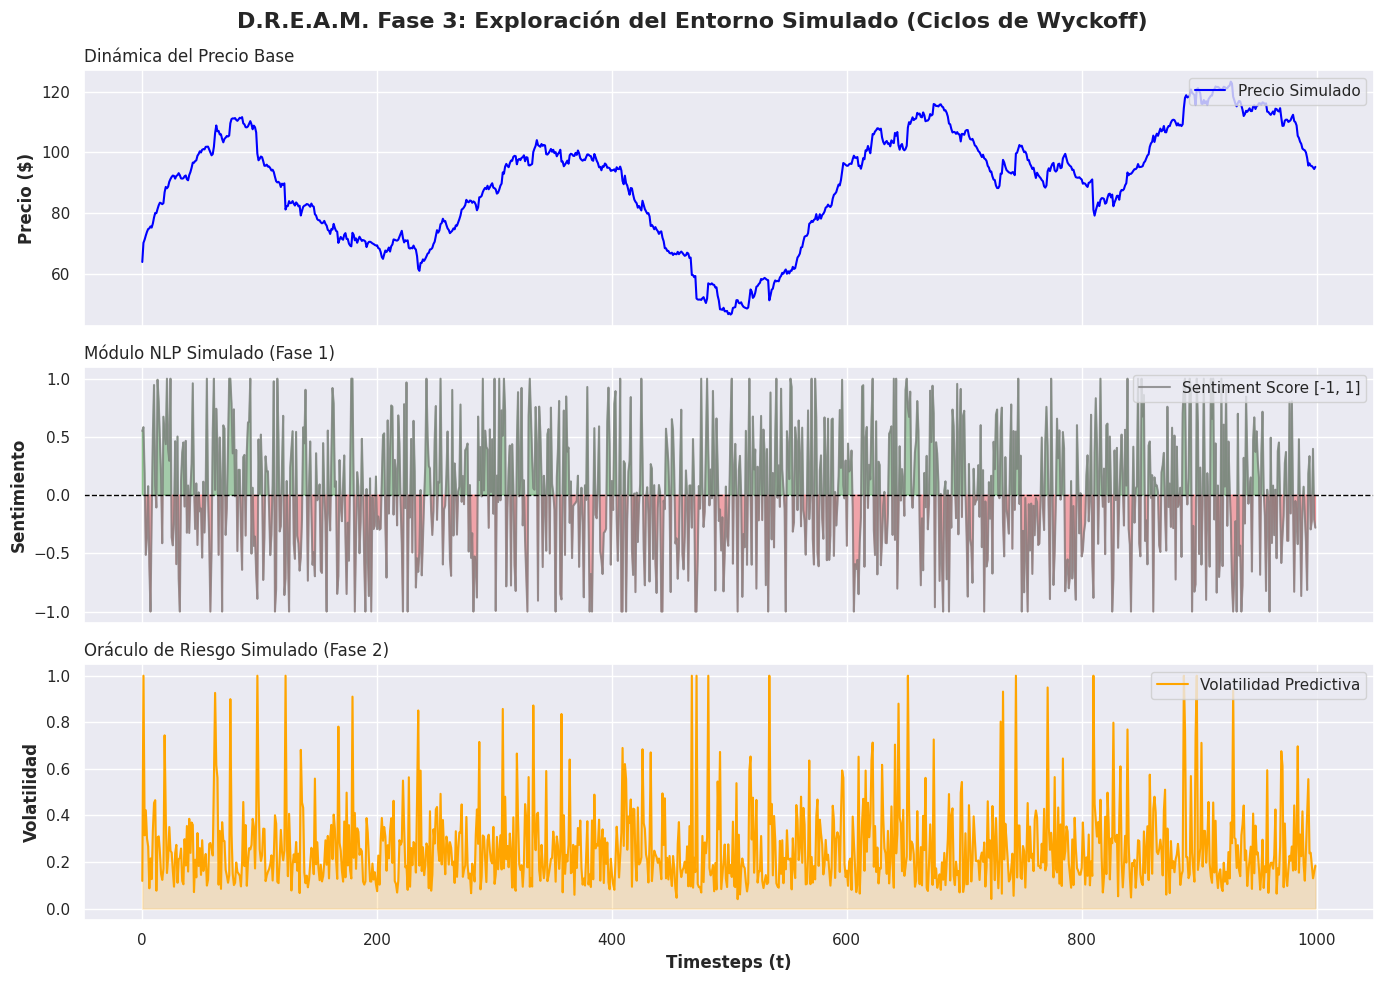


Resumen Estadístico de las Señales Simuladas:


,count,mean,std,min,25%,50%,75%,max
Step,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Price,1000.0,89.755409,18.076769,46.588807,76.289341,93.494166,102.363034,123.283722
Sentiment,1000.0,0.010812,0.532869,-1.000000,-0.391258,0.013561,0.417404,1.000000
Volatility,1000.0,0.263868,0.175033,0.040561,0.145766,0.215219,0.330179,1.000000


Generando 1000 observaciones simuladas...


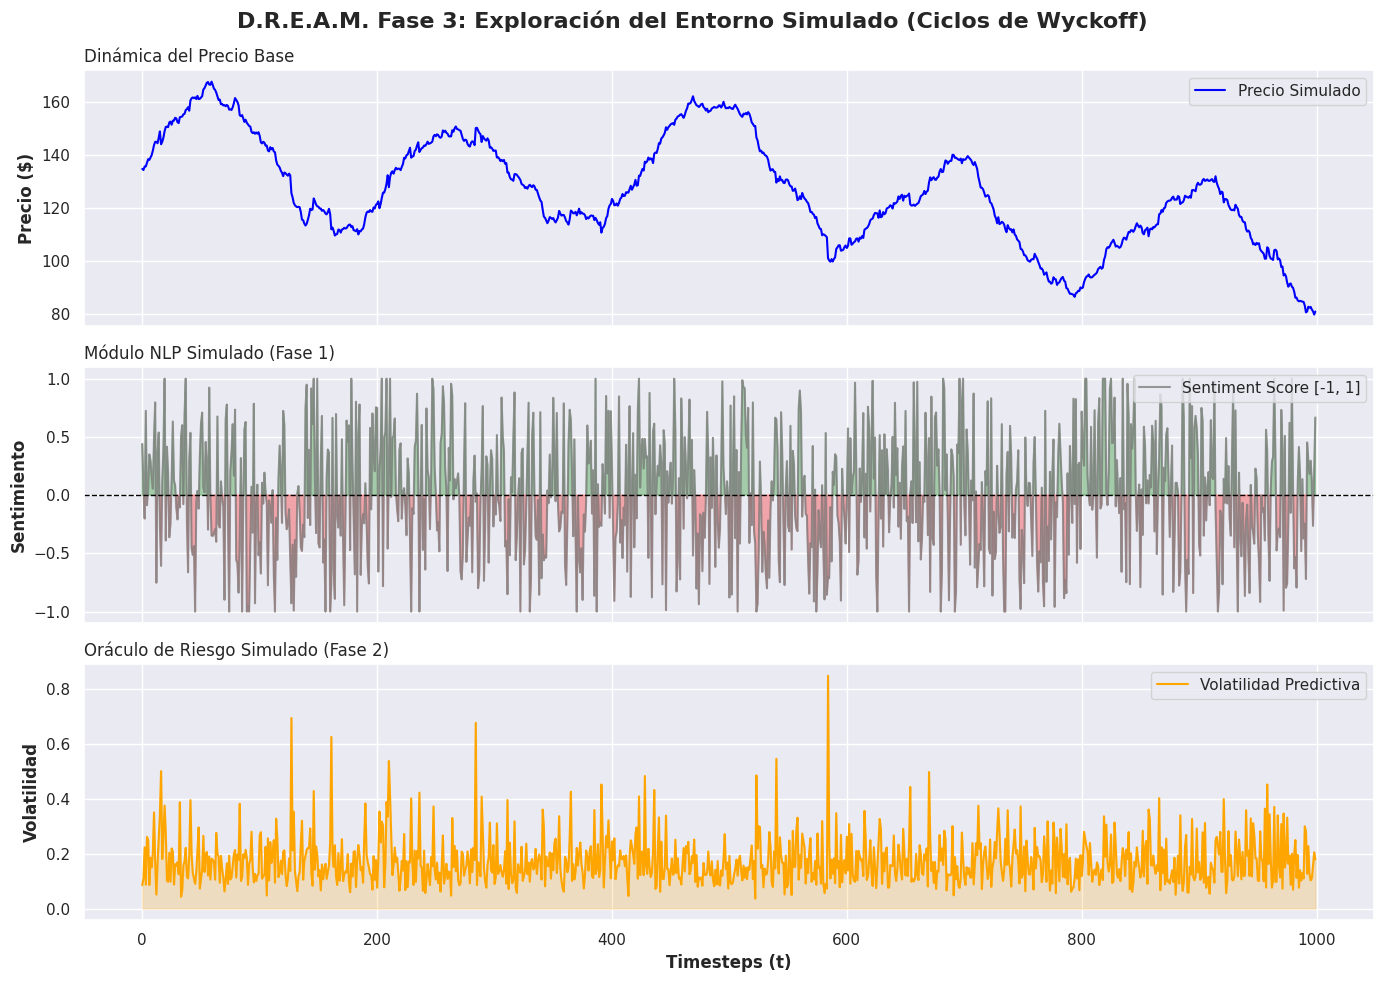


Resumen Estadístico de las Señales Simuladas:


,count,mean,std,min,25%,50%,75%,max
Step,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Price,1000.0,126.521832,19.819737,79.657746,112.784567,124.417481,142.109115,167.617525
Sentiment,1000.0,-0.001110,0.520205,-1.000000,-0.373552,-0.005669,0.388233,1.000000
Volatility,1000.0,0.174953,0.088536,0.036591,0.113461,0.156293,0.212268,0.849963


Generando 1000 observaciones simuladas...


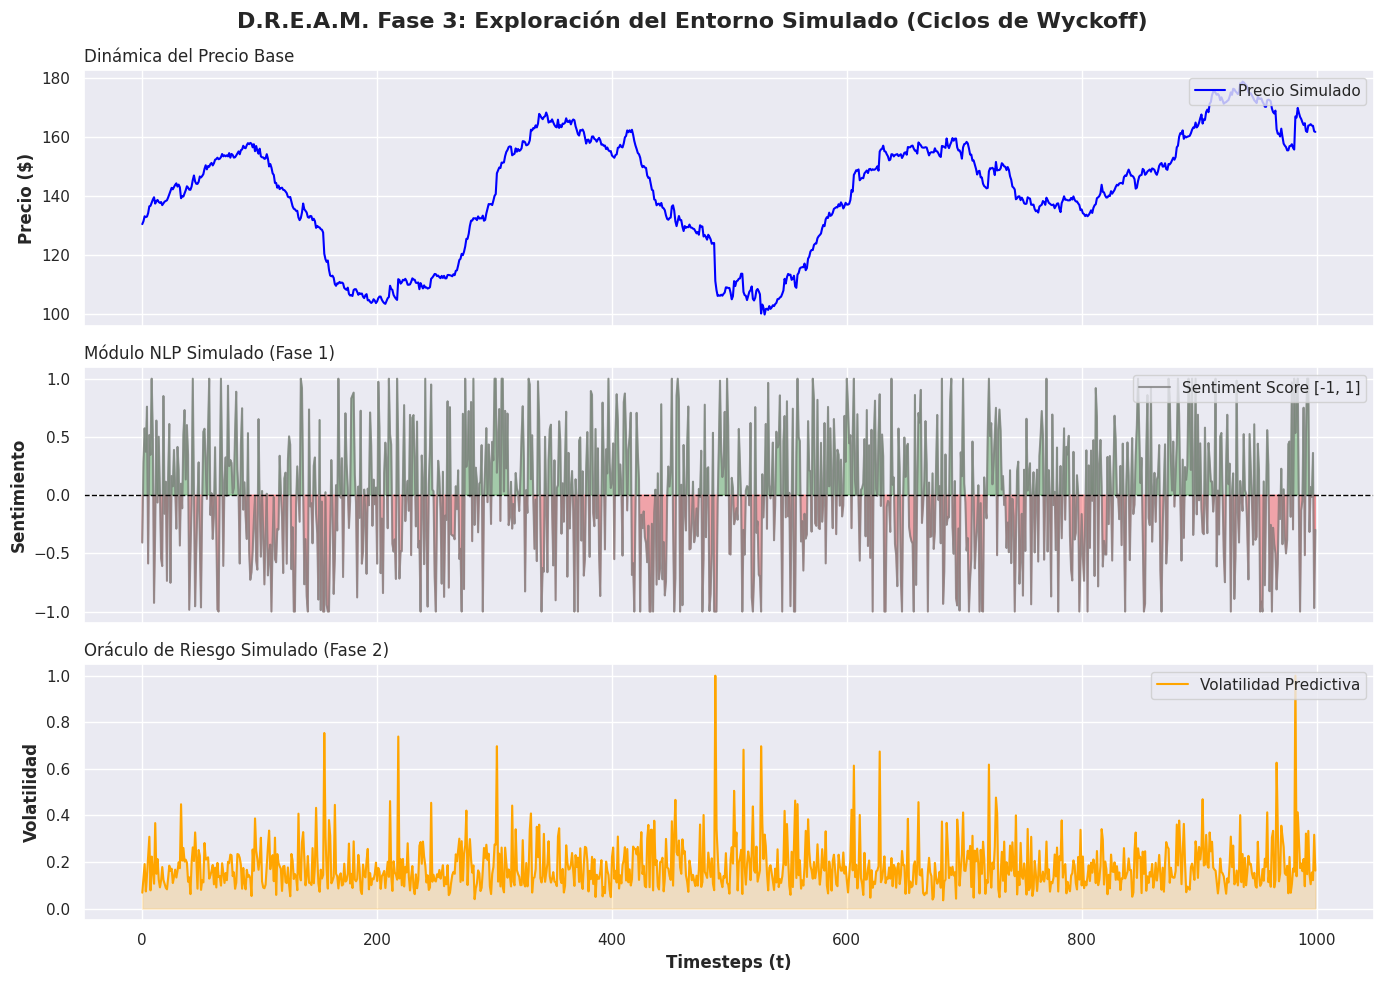


Resumen Estadístico de las Señales Simuladas:


,count,mean,std,min,25%,50%,75%,max
Step,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Price,1000.0,141.288555,19.726530,99.842037,129.883961,144.156201,156.216673,178.769757
Sentiment,1000.0,-0.007557,0.538860,-1.000000,-0.385648,0.006256,0.403750,1.000000
Volatility,1000.0,0.181260,0.103287,0.035727,0.114705,0.158158,0.217948,1.000000


Generando 1000 observaciones simuladas...


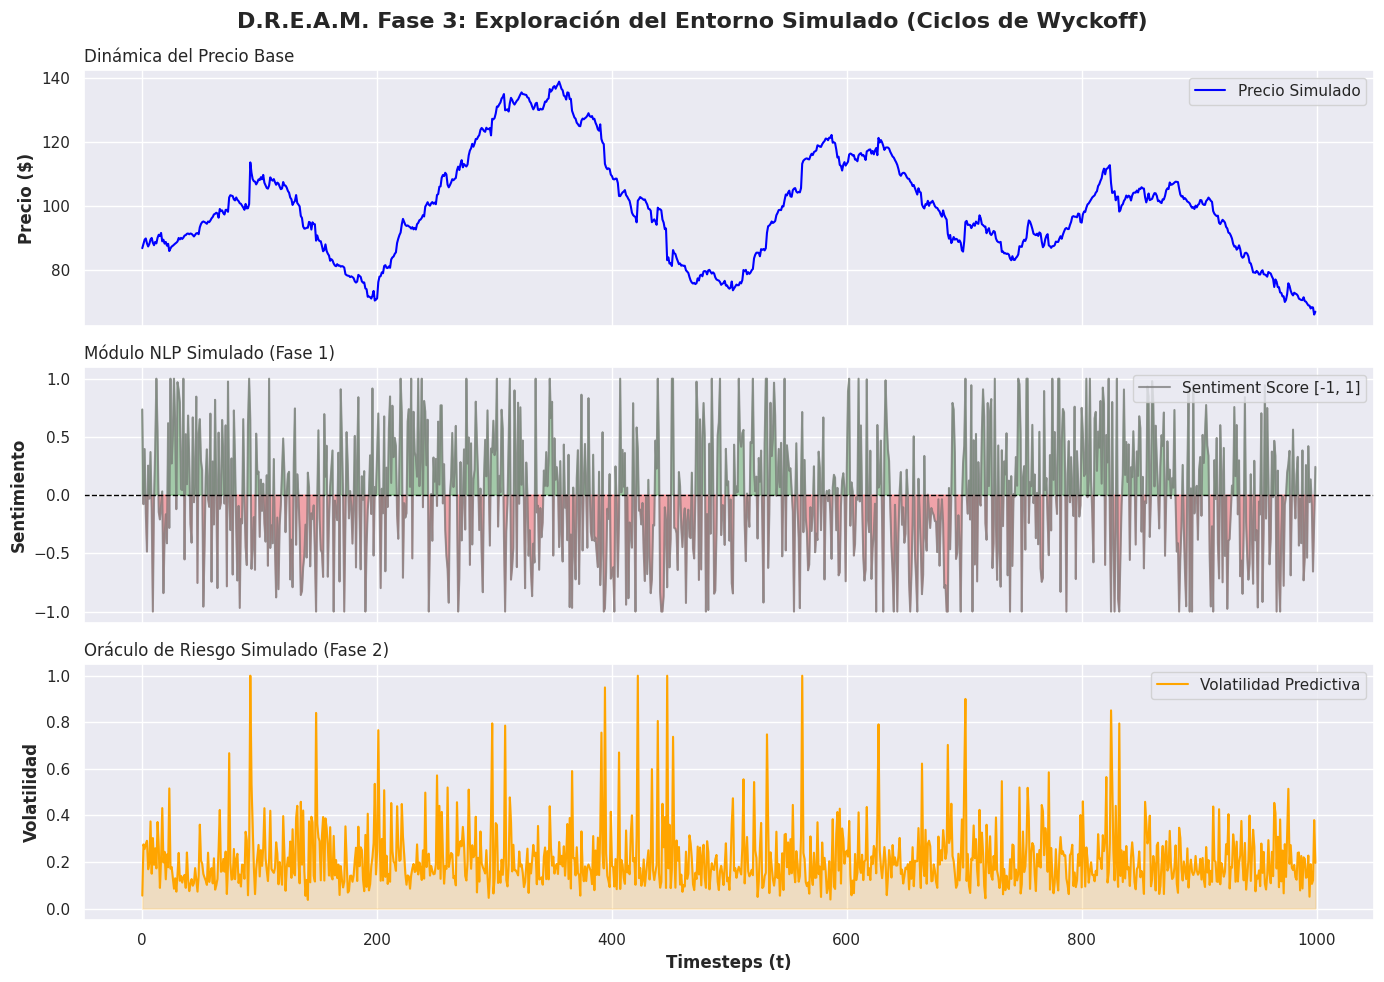


Resumen Estadístico de las Señales Simuladas:


,count,mean,std,min,25%,50%,75%,max
Step,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Price,1000.0,99.152065,16.316147,65.969112,87.645219,98.601603,108.381245,138.950533
Sentiment,1000.0,-0.011166,0.527185,-1.000000,-0.395570,-0.011611,0.369108,1.000000
Volatility,1000.0,0.216293,0.136262,0.037465,0.128392,0.181293,0.262459,1.000000


Generando 1000 observaciones simuladas...


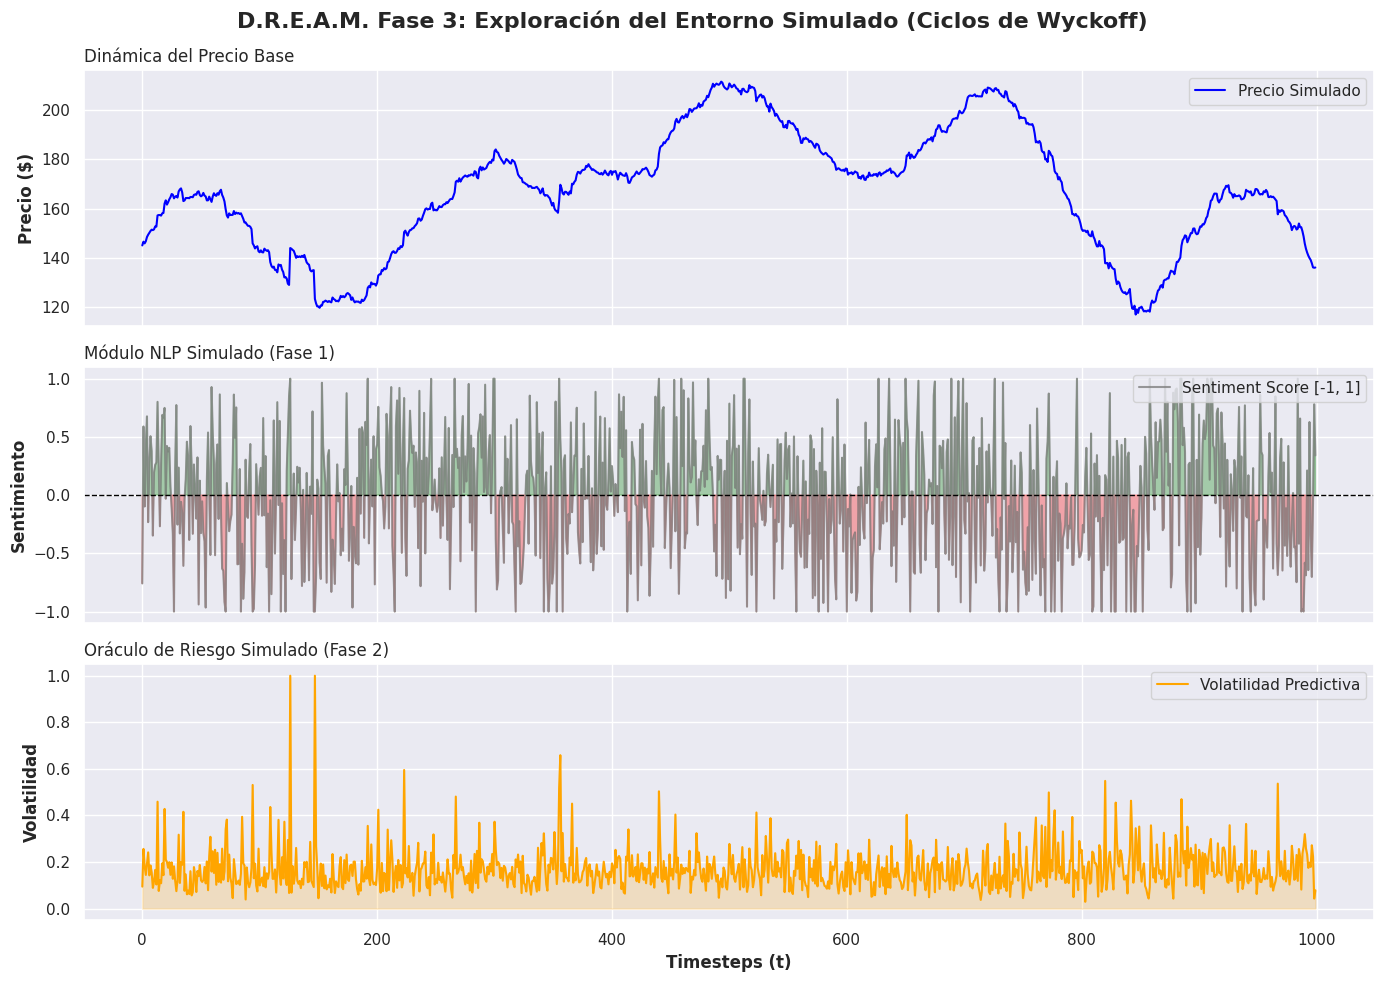


Resumen Estadístico de las Señales Simuladas:


,count,mean,std,min,25%,50%,75%,max
Step,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Price,1000.0,167.240688,24.200892,116.915078,151.063766,167.714645,182.859191,211.597692
Sentiment,1000.0,-0.014962,0.528548,-1.000000,-0.417008,0.004768,0.373302,1.000000
Volatility,1000.0,0.168857,0.090384,0.029359,0.112891,0.150422,0.201325,1.000000


In [8]:
mock_generator = RealisticMockDataGenerator2(steps=1000, cycle_length=250)

# Ejecutamos la exploración en el notebook
for _ in range(5):
    explore_mock_data(mock_generator, steps=1000)
    mock_generator.generate_new_market()